## Brightness and LIME image explainer

In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
from skimage.segmentation import mark_boundaries
from skimage.io import imsave, imshow
from astroExplain.image.neighbors import Neighbors
from astroExplain.image.explanation import TellMeWhy
from sdss.utils.managefiles import FileDirectory


# Custom functions

## Segment

In [ ]:
def segment(image, sigma, compactness, nsegments):

    slic_parameters = {"sigma": sigma, "compactness": compactness}

    nghs = Neighbors(
        image=image,
        number_segments=nsegments,
        slic_parameters=slic_parameters,
        random_seed=0,
    )

    image_with_boundaries = mark_boundaries(
        nghs.image,
        nghs.segments,
        color=(1, 1, 1),
        outline_color=(1, 1, 1),
    )

    return image_with_boundaries, nghs

## Masking

In [20]:
def mask_pertrubed_sps(
    segments: np.array, on_off_super_pixels: np.array
) -> np.array:
    """
    Obtain a mask with the number of the segment for perturbed
    super pixels. The non-perturbed super pixels has a segment
    number of zero. Remember that the number of the original
    segments range from 1 to the number of segments
    """
    new_segments = segments.copy()
    for idx_sp, on_off in enumerate(on_off_super_pixels):

        if on_off == 1:
            # segments range from 0 to the number of segments
            # that is why I use idx_sp + 1
            mask_on_sp = np.where(segments == idx_sp + 1, True, False)

            new_segments[mask_on_sp] = 0

    return new_segments

# Config

## Directories

In [15]:
data_dir = 'data/hoag'
explainers_dir = f'{data_dir}/explainers'

## Data

In [6]:
hoag_img = plt.imread(f"{data_dir}/hoag.jpg") / 255.0

(-0.5, 562.5, 550.5, -0.5)

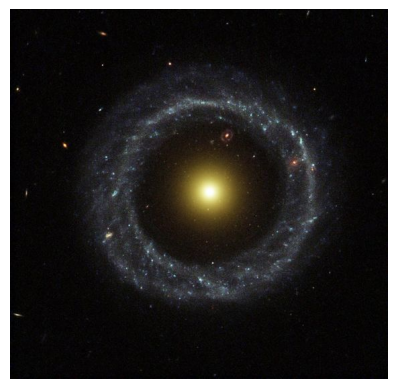

In [10]:
plt.imshow(hoag_img)
plt.axis('off')

# Squared like: compactness = 100

(-0.5, 562.5, 550.5, -0.5)

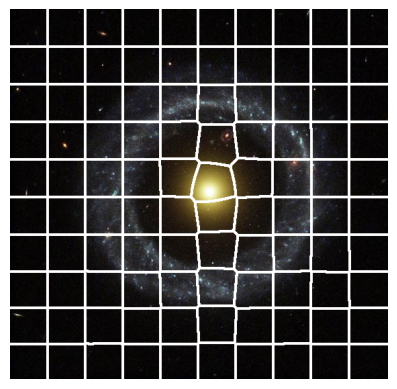

In [55]:
img_bounds_c_100, nghs = segment(
    hoag_img, sigma=16, compactness=100, nsegments=100
)
plt.imshow(img_bounds_c_100)
plt.axis('off')

## Perturbed samples

(-0.5, 562.5, 550.5, -0.5)

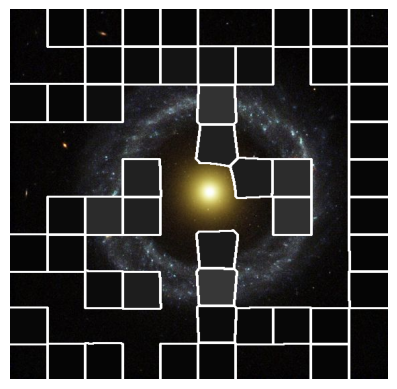

In [61]:
# selection
# n = [8, 2]
slic_parameters = {"sigma": 16, "compactness": 100}

neighbors_c_100 = Neighbors(
    image=hoag_img,
    number_segments=100,
    slic_parameters=slic_parameters,
    random_seed=0,
)
# 
(
    pert_imgs_c_100, on_off_sp_pert_c_100
) = neighbors_c_100.get_neighbors(10, None)
# 
n = 8
new_segments_c_100 = mask_pertrubed_sps(
    neighbors_c_100.segments, on_off_sp_pert_c_100[n]
)

img_bounds_n = mark_boundaries(
    pert_imgs_c_100[n],
    new_segments_c_100,
    color=(1, 1, 1),
    outline_color=(1, 1, 1),
)
plt.imshow(img_bounds_n)
plt.axis('off')

## Selection

In [58]:
img_c_100_dict = {
    'boundaries': img_bounds_c_100,
    'n1': None,
    'n2': None
}

for key, n in zip(['n1', 'n2'], [8, 2]):

    new_segments_c_100 = mask_pertrubed_sps(
        neighbors_c_100.segments, on_off_sp_pert_c_100[n]
    )

    img_bounds_n = mark_boundaries(
        pert_imgs_c_100[n],
        new_segments_c_100,
        color=(1, 1, 1),
        outline_color=(1, 1, 1),
    )

    img_c_100_dict[key] = img_bounds_n

(-0.5, 562.5, 550.5, -0.5)

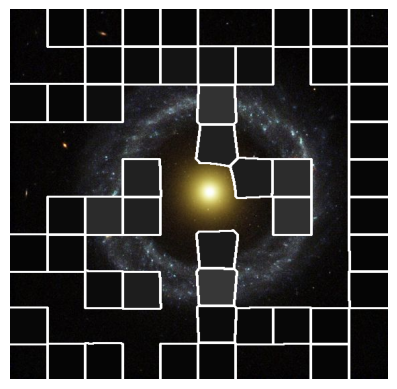

In [62]:
plt.imshow(img_c_100_dict['n1'])
plt.axis('off')

# intermediate: compactness = 10

(-0.5, 562.5, 550.5, -0.5)

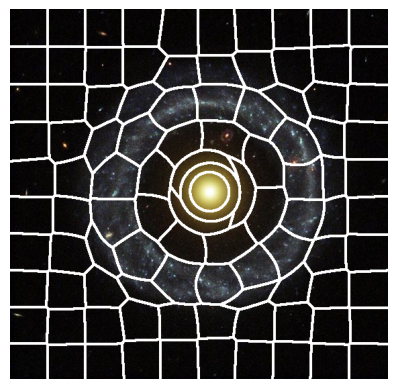

In [66]:
img_bounds_c_10, nghs = segment(
    hoag_img, sigma=16, compactness=10, nsegments=100
)
plt.imshow(img_bounds_c_10)
plt.axis('off')

## Perturbed samples

(-0.5, 562.5, 550.5, -0.5)

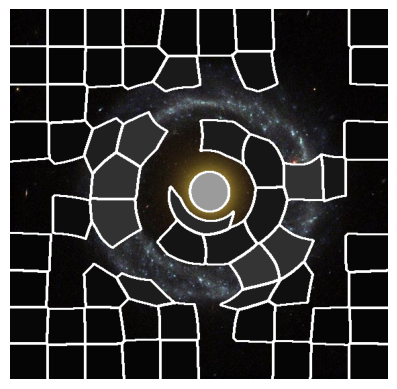

In [ ]:
# selection
# n = [2, 1]
slic_parameters = {"sigma": 16, "compactness": 10}

neighbors_c_10 = Neighbors(
    image=hoag_img,
    number_segments=100,
    slic_parameters=slic_parameters,
    random_seed=0,
)
# 
(
    pert_imgs_c_10, on_off_sp_pert_c_10
) = neighbors_c_10.get_neighbors(10, None)
# 
n = 1
new_segments_c_10 = mask_pertrubed_sps(
    neighbors_c_10.segments, on_off_sp_pert_c_10[n]
)

img_bounds_n = mark_boundaries(
    pert_imgs_c_10[n],
    new_segments_c_10,
    color=(1, 1, 1),
    outline_color=(1, 1, 1),
)
plt.imshow(img_bounds_n)
plt.axis('off')

## Selection

In [67]:
img_c_10_dict = {
    'boundaries': img_bounds_c_10,
    'n1': None,
    'n2': None
}

for key, n in zip(['n1', 'n2'], [2, 1]):

    new_segments_c_10 = mask_pertrubed_sps(
        neighbors_c_10.segments, on_off_sp_pert_c_10[n]
    )

    img_bounds_n = mark_boundaries(
        pert_imgs_c_10[n],
        new_segments_c_10,
        color=(1, 1, 1),
        outline_color=(1, 1, 1),
    )

    img_c_10_dict[key] = img_bounds_n

(-0.5, 562.5, 550.5, -0.5)

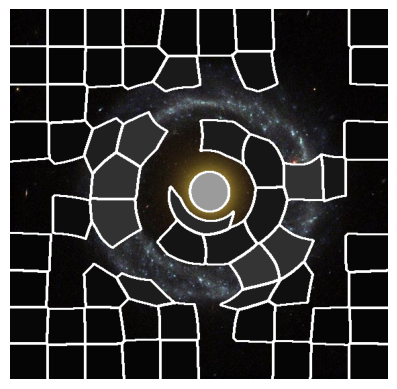

In [70]:
plt.imshow(img_c_10_dict['n2'])
plt.axis('off')

# High: compactness = 1

(-0.5, 562.5, 550.5, -0.5)

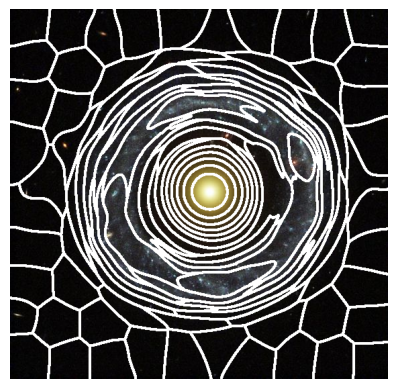

In [72]:
img_bounds_c_1, nghs = segment(
    hoag_img, sigma=16, compactness=1, nsegments=100
)
plt.imshow(img_bounds_c_1)
plt.axis('off')

## Perturbed samples

(-0.5, 562.5, 550.5, -0.5)

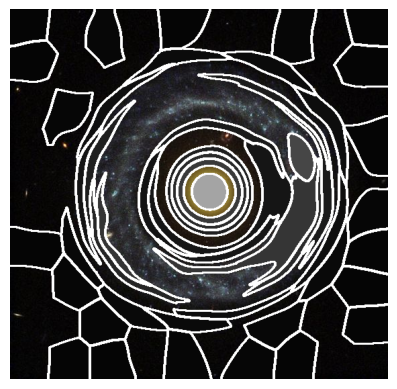

In [ ]:
# selection
# n = [8, 7]
slic_parameters = {"sigma": 16, "compactness": 1}

neighbors_c_1 = Neighbors(
    image=hoag_img,
    number_segments=100,
    slic_parameters=slic_parameters,
    random_seed=0,
)
# 
(
    pert_imgs_c_1, on_off_sp_pert_c_1
) = neighbors_c_1.get_neighbors(10, None)
# 
n = 7
new_segments_c_1 = mask_pertrubed_sps(
    neighbors_c_1.segments, on_off_sp_pert_c_1[n]
)

img_bounds_n = mark_boundaries(
    pert_imgs_c_1[n],
    new_segments_c_1,
    color=(1, 1, 1),
    outline_color=(1, 1, 1),
)
plt.imshow(img_bounds_n)
plt.axis('off')


## Selection

In [75]:
img_c_1_dict = {
    'boundaries': img_bounds_c_1,
    'n1': None,
    'n2': None
}

for key, n in zip(['n1', 'n2'], [2, 1]):

    new_segments_c_1 = mask_pertrubed_sps(
        neighbors_c_1.segments, on_off_sp_pert_c_1[n]
    )

    img_bounds_n = mark_boundaries(
        pert_imgs_c_1[n],
        new_segments_c_1,
        color=(1, 1, 1),
        outline_color=(1, 1, 1),
    )

    img_c_1_dict[key] = img_bounds_n

(-0.5, 562.5, 550.5, -0.5)

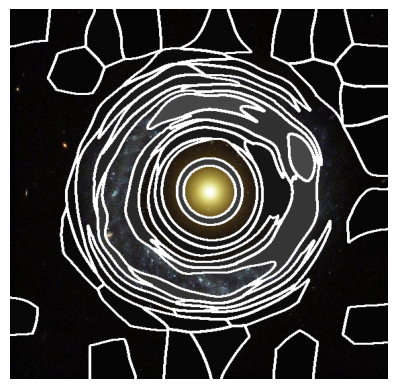

In [77]:
plt.imshow(img_c_1_dict['n1'])
plt.axis('off')

# Explanation

Get heat map of explanation


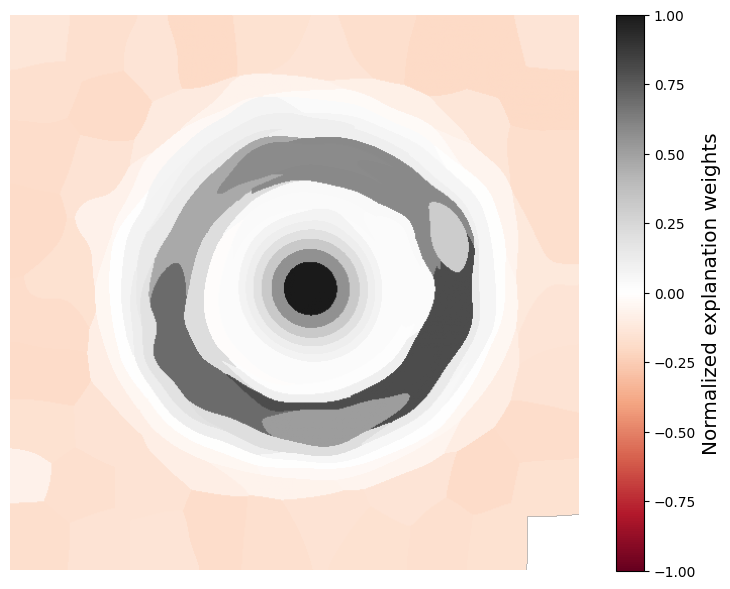

In [16]:
# explainer_pkl = "weird_hide_none_base_mean_100_compactness_10.pkl"
# explainer_pkl = "weird_hide_0.08_base_mean_100_compactness_100.pkl"
# explainer_pkl = "weird_hide_0.08_base_mean_100_compactness_10.pkl"
explainer_pkl = "weird_hide_0.08_base_mean_100_compactness_1.pkl"

with open(f"{explainers_dir}/{explainer_pkl}", "rb") as file:

    explainer = pickle.load(file)
    why = TellMeWhy(explainer)

weights_map = why.get_heatmap()
weights_map *= 1 / np.nanmax(np.abs(weights_map))
plt.figure(figsize=(8, 6))
# fig, axs = plt.subplots(nrows=1, ncols=2 ,tight_layout=True)
# axs[0].imshow(image_with_boundaries)
# axs[1].imshow(weights_map, cmap="RdGy", vmin=-1, vmax=1)
# fig.colorbar(axs[1])
plt.clf()
plt.imshow(weights_map, cmap="RdGy", vmin=-1, vmax=1)
cbar = plt.colorbar(
    # label="Normalized explanation weights"
)
cbar.ax.set_ylabel(
    "Normalized explanation weights",
    # rotation=270,
    fontsize="x-large",
)
plt.axis("off")
plt.tight_layout()

# save_to = "/home/edgar/explain-me-why/sections/figures/lime/hoag_object"
# # plt.savefig(f"{save_to}/{explanation_file}.pdf")
# plt.savefig(f"{save_to}/{explanation_file}.png")
# # imsave(f"{save_to}/{explanation_file}.png", weights_map)